# Comparación reproducible de superresolución sobre SMB

Notebook principal del experimento acelerado: muestra fija de 64 páginas independientes, seis degradaciones controladas, bicúbica, EDSR-baseline y SwinIR-lightweight. SMB se usa exclusivamente para evaluación; no se ajusta ni se elige ningún método con sus resultados.

## Contexto y método

La comparación contrasta una interpolación transparente, una CNN residual y un Transformer ligero. Los checkpoints x2/x4 proceden de los repositorios oficiales y se verifican por SHA-256 antes de cargar. La muestra fue seleccionada por rango SHA-256 antes de observar resultados y contiene 64 grupos fuente distintos.

### Supuestos clave

- EDSR-baseline y SwinIR-lightweight fueron entrenados para degradación bicúbica; las condiciones moderate/strong miden transferencia fuera de esa degradación de entrenamiento.
- Las conclusiones se limitan a la muestra fija; no se estimará prevalencia para las 685 páginas.
- El notebook no abre SMB hasta que existe un desbloqueo científico completo y revisado.

## Preparación del entorno

Local: ejecutar previamente `uv sync --extra cpu --group dev --group notebooks --group kaggle`.

Kaggle: activar GPU e Internet y guardar `HF_TOKEN` en Secrets. La celda clona el mismo repositorio si hace falta e instala el proyecto con `uv`; conserva la versión de PyTorch/CUDA suministrada por Kaggle.

In [3]:
from __future__ import annotations

import json
import os
import platform
import shutil
import subprocess
import sys
from pathlib import Path

REPOSITORY_URL = "https://github.com/dreinon/proyecto-tfg.git"
IS_KAGGLE = Path("/kaggle/working").is_dir()


def discover_project_root() -> Path:
    starts = [Path.cwd(), Path("/kaggle/working/proyecto-tfg")]
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pyproject.toml").is_file():
                return candidate.resolve()
    if not IS_KAGGLE:
        raise RuntimeError("No se encuentra el repositorio del proyecto.")
    if shutil.which("uv") is None:
        raise RuntimeError("El runtime de Kaggle no incluye uv; instálalo y vuelve a ejecutar.")
    destination = Path("/kaggle/working/proyecto-tfg")
    subprocess.run(["git", "clone", "--depth", "1", REPOSITORY_URL, str(destination)], check=True)
    return destination.resolve()


PROJECT_ROOT = discover_project_root()
if IS_KAGGLE:
    if shutil.which("uv") is None:
        raise RuntimeError("uv es obligatorio para preparar el runtime de Kaggle.")
    torch_before = subprocess.run(
        [sys.executable, "-c", "import torch; print(torch.__version__)"],
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    subprocess.run(
        ["uv", "pip", "install", "--system", "--no-deps", "-e", str(PROJECT_ROOT)],
        check=True,
    )
    subprocess.run(
        [
            "uv",
            "pip",
            "install",
            "--system",
            "--no-deps",
            "spandrel==0.4.2",
            "einops==0.8.2",
        ],
        check=True,
    )
    torch_after = subprocess.run(
        [sys.executable, "-c", "import torch; print(torch.__version__)"],
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    if torch_after != torch_before:
        raise RuntimeError("La preparación reemplazó PyTorch; reinicia y revisa el runtime.")

os.chdir(PROJECT_ROOT)
PROJECT_ROOT

Using Python 3.12.13 environment at: /usr
Resolved 1 package in 72ms
Prepared 1 package in 730ms
Installed 1 package in 1ms
 + score-super-resolution==0.1.0 (from file:///kaggle/working/proyecto-tfg)
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 97ms
Prepared 1 package in 116ms
Installed 1 package in 14ms
 + spandrel==0.4.2


PosixPath('/kaggle/working/proyecto-tfg')

In [4]:
import subprocess

subprocess.run(
    [
        "uv",
        "pip",
        "install",
        "--system",
        "cairosvg==2.9.0",
        "verovio==6.2.1",
    ],
    check=True,
)

Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 305ms


Prepared 4 packages in 796ms
Installed 4 packages in 68ms
 + cairocffi==1.7.1
 + cairosvg==2.9.0
 + cssselect2==0.9.0
 + verovio==6.2.1


CompletedProcess(args=['uv', 'pip', 'install', '--system', 'cairosvg==2.9.0', 'verovio==6.2.1'], returncode=0)

In [5]:
import sys

source_path = str(PROJECT_ROOT / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)

In [6]:
if IS_KAGGLE:
    from kaggle_secrets import UserSecretsClient

    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

In [7]:
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

from score_super_resolution.benchmark_policy import BenchmarkPurpose, BenchmarkState
from score_super_resolution.comparison import (
    CONDITIONS,
    QUALITATIVE_ASSIGNMENT,
    as_rgb8,
    ensure_manifest_generation,
    fidelity_metrics,
    load_evaluation_sample,
    load_frozen_degradation,
    technical_smoke_image,
)
from score_super_resolution.degradation import align_reference, apply_degradation
from score_super_resolution.pretrained import MODEL_METHODS, PretrainedSRRunner
from score_super_resolution.smb import check_access, load_smb

SEED = 20260829
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

EXPERIMENT_PATH = PROJECT_ROOT / "configs/experiments/smb-pretrained-evaluation-v1.yaml"
UNLOCK_PATH = PROJECT_ROOT / "configs/smb-evaluation-v1/unlock.json"
GENERATION_ROOT = ensure_manifest_generation(PROJECT_ROOT)
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts/phase3-smb-evaluation"
experiment = yaml.safe_load(EXPERIMENT_PATH.read_text(encoding="utf-8"))
evaluation_unlocked = experiment["status"] == "frozen" and UNLOCK_PATH.is_file()
run_smb_evaluation = IS_KAGGLE or os.environ.get("RUN_SMB_EVALUATION") == "1"
evaluation_ready = evaluation_unlocked and run_smb_evaluation
{
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "seed": SEED,
    "evaluation_unlocked": evaluation_unlocked,
    "run_smb_evaluation": run_smb_evaluation,
    "evaluation_ready": evaluation_ready,
}

{'python': '3.12.13',
 'torch': '2.10.0+cu128',
 'cuda_runtime': '12.8',
 'device': 'Tesla T4',
 'seed': 20260829,
 'evaluation_unlocked': True,
 'run_smb_evaluation': True,
 'evaluation_ready': True}

In [8]:
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

from score_super_resolution.benchmark_policy import BenchmarkPurpose, BenchmarkState
from score_super_resolution.comparison import (
    CONDITIONS,
    QUALITATIVE_ASSIGNMENT,
    as_rgb8,
    ensure_manifest_generation,
    fidelity_metrics,
    load_evaluation_sample,
    load_frozen_degradation,
    technical_smoke_image,
)
from score_super_resolution.degradation import align_reference, apply_degradation
from score_super_resolution.pretrained import MODEL_METHODS, PretrainedSRRunner
from score_super_resolution.smb import check_access, load_smb

SEED = 20260829
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

EXPERIMENT_PATH = PROJECT_ROOT / "configs/experiments/smb-pretrained-evaluation-v1.yaml"
UNLOCK_PATH = PROJECT_ROOT / "configs/smb-evaluation-v1/unlock.json"
GENERATION_ROOT = ensure_manifest_generation(PROJECT_ROOT)
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts/phase3-smb-evaluation"
experiment = yaml.safe_load(EXPERIMENT_PATH.read_text(encoding="utf-8"))
evaluation_unlocked = experiment["status"] == "frozen" and UNLOCK_PATH.is_file()
run_smb_evaluation = IS_KAGGLE or os.environ.get("RUN_SMB_EVALUATION") == "1"
evaluation_ready = evaluation_unlocked and run_smb_evaluation
{
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "seed": SEED,
    "evaluation_unlocked": evaluation_unlocked,
    "run_smb_evaluation": run_smb_evaluation,
    "evaluation_ready": evaluation_ready,
}

{'python': '3.12.13',
 'torch': '2.10.0+cu128',
 'cuda_runtime': '12.8',
 'device': 'Tesla T4',
 'seed': 20260829,
 'evaluation_unlocked': True,
 'run_smb_evaluation': True,
 'evaluation_ready': True}

In [9]:
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

from score_super_resolution.benchmark_policy import BenchmarkPurpose, BenchmarkState
from score_super_resolution.comparison import (
    CONDITIONS,
    QUALITATIVE_ASSIGNMENT,
    as_rgb8,
    ensure_manifest_generation,
    fidelity_metrics,
    load_evaluation_sample,
    load_frozen_degradation,
    technical_smoke_image,
)
from score_super_resolution.degradation import align_reference, apply_degradation
from score_super_resolution.pretrained import MODEL_METHODS, PretrainedSRRunner
from score_super_resolution.smb import check_access, load_smb

SEED = 20260829
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

EXPERIMENT_PATH = PROJECT_ROOT / "configs/experiments/smb-pretrained-evaluation-v1.yaml"
UNLOCK_PATH = PROJECT_ROOT / "configs/smb-evaluation-v1/unlock.json"
GENERATION_ROOT = ensure_manifest_generation(PROJECT_ROOT)
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts/phase3-smb-evaluation"
experiment = yaml.safe_load(EXPERIMENT_PATH.read_text(encoding="utf-8"))
evaluation_unlocked = experiment["status"] == "frozen" and UNLOCK_PATH.is_file()
run_smb_evaluation = IS_KAGGLE or os.environ.get("RUN_SMB_EVALUATION") == "1"
evaluation_ready = evaluation_unlocked and run_smb_evaluation
{
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "seed": SEED,
    "evaluation_unlocked": evaluation_unlocked,
    "run_smb_evaluation": run_smb_evaluation,
    "evaluation_ready": evaluation_ready,
}

{'python': '3.12.13',
 'torch': '2.10.0+cu128',
 'cuda_runtime': '12.8',
 'device': 'Tesla T4',
 'seed': 20260829,
 'evaluation_unlocked': True,
 'run_smb_evaluation': True,
 'evaluation_ready': True}

## Datos

In [10]:
access = check_access()
sample = load_evaluation_sample(PROJECT_ROOT)
sample_frame = pd.DataFrame([row.__dict__ for row in sample])
pd.DataFrame(
    [
        {
            "repository": access.get("repository_id"),
            "revision": access.get("resolved_revision"),
            "access_status": access.get("status"),
            "descriptor_match": access.get("descriptor_match"),
            "sample_pages": len(sample_frame),
            "independent_source_groups": sample_frame.source_group_id.nunique(),
        }
    ]
)

README.md: 0.00B [00:00, ?B/s]

,repository,revision,access_status,descriptor_match,sample_pages,independent_source_groups
0,PRAIG/SMB,96332e8c4ac81cbdb7f61093ec5a4bfff76a0adb,accessible,True,64,64


## Métodos y smoke test técnico

In [11]:
runner = PretrainedSRRunner(
    PROJECT_ROOT,
    tile_size=int(experiment["inference"]["tile_size"]),
    tile_overlap=int(experiment["inference"]["tile_overlap"]),
)
checkpoint_paths = runner.prepare()
pd.DataFrame(
    [
        {"checkpoint": key, "available": Path(value).is_file()}
        for key, value in checkpoint_paths.items()
    ]
)

,checkpoint,available
0,edsr-baseline-official-v1-x2,True
1,edsr-baseline-official-v1-x4,True
2,swinir-lightweight-official-v1-x2,True
3,swinir-lightweight-official-v1-x4,True


In [12]:
smoke_hr = technical_smoke_image()
smoke_rows = []
for scale in (2, 4):
    condition_id = f"x{scale}-clean"
    smoke_lr = cv2.resize(
        smoke_hr,
        (smoke_hr.shape[1] // scale, smoke_hr.shape[0] // scale),
        interpolation=cv2.INTER_AREA,
    )
    for method_id in MODEL_METHODS:
        result = runner.run(
            method_id, smoke_lr, target_shape=smoke_hr.shape, condition_id=condition_id
        )
        smoke_rows.append(
            {
                "scale": scale,
                "method": method_id,
                "shape_ok": result.pixels.shape == smoke_hr.shape,
                "runtime_seconds": result.elapsed_ns / 1e9,
                "parameters": result.evidence.get("parameter_count"),
            }
        )
smoke_results = pd.DataFrame(smoke_rows)
smoke_results

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


,scale,method,shape_ok,runtime_seconds,parameters
0,2,bicubic-opencv-v1,True,0.028084,NaN
1,2,edsr-baseline-official-v1,True,0.940129,1369883.0
2,2,swinir-lightweight-official-v1,True,0.213939,910152.0
3,4,bicubic-opencv-v1,True,0.000067,NaN
4,4,edsr-baseline-official-v1,True,0.007699,1517595.0
5,4,swinir-lightweight-official-v1,True,0.036147,929628.0


El smoke test anterior solo comprueba descarga, carga, dimensiones e inferencia; no es evidencia musical ni se utilizará en las conclusiones.

## Ejecución SMB

In [13]:
if not evaluation_ready:
    reason = (
        "falta el desbloqueo científico"
        if not evaluation_unlocked
        else "ejecución local desactivada; usa Kaggle o RUN_SMB_EVALUATION=1"
    )
    print(f"Evaluación SMB no iniciada: {reason}.")
    dataset = None
else:
    unlock = json.loads(UNLOCK_PATH.read_text(encoding="utf-8"))
    dataset = load_smb(
        purpose=BenchmarkPurpose.INFERENCE,
        state=BenchmarkState.EVALUATION_UNLOCKED,
        unlock_record=unlock,
        project_root=PROJECT_ROOT,
        manifest_generation_root=GENERATION_ROOT,
    )
    print(f"SMB cargado en la revisión fijada: {len(dataset)} páginas.")

data/test-00000-of-00001.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/685 [00:00<?, ? examples/s]

SMB cargado en la revisión fijada: 685 páginas.


In [14]:
RESULTS_PATH = ARTIFACT_ROOT / "raw-metrics.csv"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
results = pd.read_csv(RESULTS_PATH) if RESULTS_PATH.is_file() else pd.DataFrame()

if dataset is not None:
    degradation = load_frozen_degradation(PROJECT_ROOT)
    completed = (
        set()
        if results.empty
        else set(zip(results.item_id, results.condition_id, results.method_id, strict=True))
    )
    records = results.to_dict("records") if not results.empty else []
    qualitative_lookup = dict(QUALITATIVE_ASSIGNMENT)
    for sample_row in sample:
        hr_original = as_rgb8(dataset[sample_row.upstream_index]["image"])
        for condition_id in CONDITIONS:
            scale = int(condition_id[1])
            degraded = apply_degradation(
                hr_original,
                control=degradation,
                condition_id=condition_id,
                item_id=sample_row.item_id,
                source_group_id=sample_row.source_group_id,
                fixture_manifest_id="smb-pretrained-evaluation-v1",
                purpose="benchmark",
            )
            reference = align_reference(hr_original, scale).pixels
            for method_id in MODEL_METHODS:
                key = (sample_row.item_id, condition_id, method_id)
                if key in completed:
                    continue
                reconstruction = runner.run(
                    method_id,
                    degraded.pixels,
                    target_shape=reference.shape,
                    condition_id=condition_id,
                )
                metrics = fidelity_metrics(reference, reconstruction.pixels)
                records.append(
                    {
                        "upstream_index": sample_row.upstream_index,
                        "item_id": sample_row.item_id,
                        "source_group_id": sample_row.source_group_id,
                        "condition_id": condition_id,
                        "scale": scale,
                        "profile": condition_id.split("-", 1)[1],
                        "method_id": method_id,
                        **metrics,
                        "runtime_seconds": reconstruction.elapsed_ns / 1e9,
                        "degradation_trace_id": degraded.trace["trace_id"],
                        "output_sha256": reconstruction.evidence["output_pixel_sha256"],
                        "checkpoint_sha256": reconstruction.evidence.get("checkpoint_sha256"),
                    }
                )
                if qualitative_lookup.get(sample_row.item_id) == condition_id:
                    output_dir = ARTIFACT_ROOT / "qualitative" / sample_row.item_id / condition_id
                    output_dir.mkdir(parents=True, exist_ok=True)
                    cv2.imwrite(
                        str(output_dir / f"{method_id}.png"),
                        cv2.cvtColor(reconstruction.pixels, cv2.COLOR_RGB2BGR),
                    )
            results = pd.DataFrame(records)
        temporary = RESULTS_PATH.with_suffix(".csv.tmp")
        results.to_csv(temporary, index=False)
        os.replace(temporary, RESULTS_PATH)
    print(
        f"Tuplas reconciliadas: {len(results)} / "
        f"{len(sample) * len(CONDITIONS) * len(MODEL_METHODS)}"
    )
results.head() if not results.empty else results

Tuplas reconciliadas: 1152 / 1152


,upstream_index,item_id,source_group_id,condition_id,scale,profile,method_id,psnr_y,ssim_y,psnr_rgb,ssim_rgb,runtime_seconds,degradation_trace_id,output_sha256,checkpoint_sha256
0,6,smb-test-000006,beethoven_sonata11_4_p2,x2-clean,2,clean,bicubic-opencv-v1,19.256400,0.878919,17.934479,0.875410,0.004137,degradation-1a0ef7857c2368b265503bc01bbe9aec56...,eb066f068d2afb61b356db95683acc20de8f7f13628013...,NaN
1,6,smb-test-000006,beethoven_sonata11_4_p2,x2-clean,2,clean,edsr-baseline-official-v1,23.013567,0.958906,21.691033,0.956122,0.614290,degradation-1a0ef7857c2368b265503bc01bbe9aec56...,d37029d40bc421ffd5ef8fde8e5eb01570482e9c9ddd02...,1bc9523228fdc3b0a5ddb0d7062001e22b31bbb398ae09...
2,6,smb-test-000006,beethoven_sonata11_4_p2,x2-clean,2,clean,swinir-lightweight-official-v1,23.754553,0.967537,22.418830,0.965860,5.762149,degradation-1a0ef7857c2368b265503bc01bbe9aec56...,4522cd749109c253dc50f43133704b513d99911494303d...,193b229909ca89cd8b55de9c9e7fce146ae759d59dfcd7...
3,6,smb-test-000006,beethoven_sonata11_4_p2,x2-moderate,2,moderate,bicubic-opencv-v1,15.878506,0.692905,14.556585,0.682453,0.003818,degradation-2217c837fe4f625ca8dac7254a6f77b220...,f9800a3f8d845764f3c5590c6c8daa7697365ea169f33a...,NaN
4,6,smb-test-000006,beethoven_sonata11_4_p2,x2-moderate,2,moderate,edsr-baseline-official-v1,15.939553,0.695411,14.618190,0.684181,0.604689,degradation-2217c837fe4f625ca8dac7254a6f77b220...,bfbfada70eee52abb741733da2b975c2b219d9277dd1c8...,1bc9523228fdc3b0a5ddb0d7062001e22b31bbb398ae09...


## Resultados

In [15]:
if results.empty:
    aggregate = pd.DataFrame()
else:
    aggregate = results.groupby(["condition_id", "method_id"], as_index=False).agg(
        pages=("item_id", "nunique"),
        psnr_y_mean=("psnr_y", "mean"),
        ssim_y_mean=("ssim_y", "mean"),
        psnr_rgb_mean=("psnr_rgb", "mean"),
        ssim_rgb_mean=("ssim_rgb", "mean"),
        runtime_seconds_median=("runtime_seconds", "median"),
    )
aggregate

,condition_id,method_id,pages,psnr_y_mean,ssim_y_mean,psnr_rgb_mean,ssim_rgb_mean,runtime_seconds_median
0,x2-clean,bicubic-opencv-v1,64,21.532487,0.908615,20.210363,0.904754,0.005048
1,x2-clean,edsr-baseline-official-v1,64,25.405573,0.962899,24.074273,0.959493,0.691812
2,x2-clean,swinir-lightweight-official-v1,64,26.441796,0.970554,25.108214,0.968477,5.554325
3,x2-moderate,bicubic-opencv-v1,64,17.283496,0.742591,15.960621,0.729863,0.005048
4,x2-moderate,edsr-baseline-official-v1,64,17.367682,0.745969,16.045349,0.732440,0.710209
5,x2-moderate,swinir-lightweight-official-v1,64,17.382298,0.745356,16.059427,0.731675,5.478193
6,x2-strong,bicubic-opencv-v1,64,14.177384,0.568344,12.853546,0.552813,0.004990
7,x2-strong,edsr-baseline-official-v1,64,14.167230,0.563250,12.843424,0.547104,0.703579
8,x2-strong,swinir-lightweight-official-v1,64,14.166490,0.562276,12.842772,0.545977,5.559909
9,x4-clean,bicubic-opencv-v1,64,17.119507,0.742816,15.797258,0.733411,0.003402


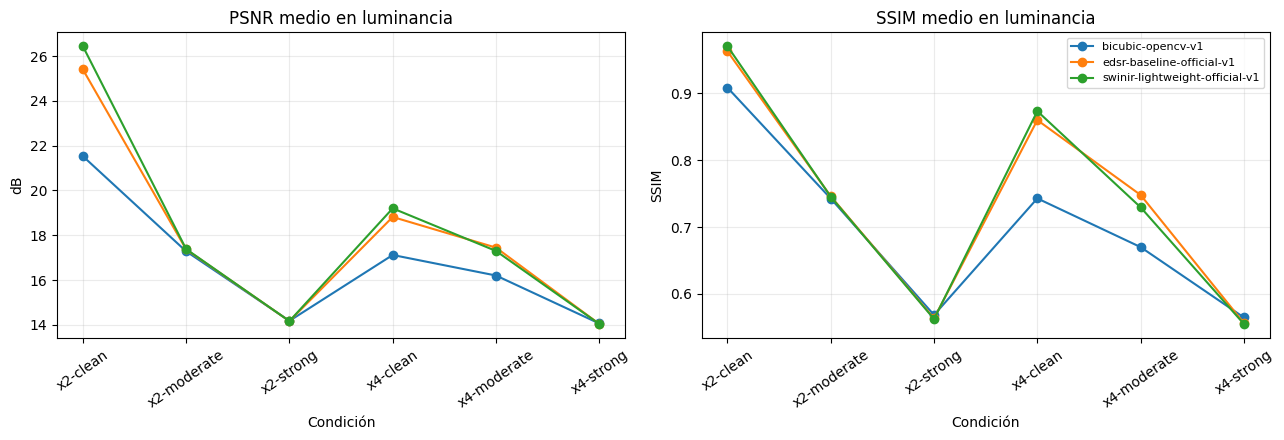

In [16]:
if not aggregate.empty:
    figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for method_id, frame in aggregate.groupby("method_id"):
        axes[0].plot(frame.condition_id, frame.psnr_y_mean, marker="o", label=method_id)
        axes[1].plot(frame.condition_id, frame.ssim_y_mean, marker="o", label=method_id)
    axes[0].set(title="PSNR medio en luminancia", ylabel="dB", xlabel="Condición")
    axes[1].set(title="SSIM medio en luminancia", ylabel="SSIM", xlabel="Condición")
    for axis in axes:
        axis.tick_params(axis="x", rotation=35)
        axis.grid(alpha=0.25)
    axes[1].legend(fontsize=8)
    figure.tight_layout()
else:
    print("Todavía no hay resultados SMB que representar.")

## Conclusiones

Las conclusiones se redactarán únicamente después de ejecutar la matriz completa, reconciliar las 1.152 tuplas y revisar las seis comparaciones cualitativas preasignadas. Hasta entonces no se promoverá ninguna afirmación sobre calidad, fidelidad musical o uso profesional.

In [1]:
from pathlib import Path
import pandas as pd

artifact_root = Path("/kaggle/working/proyecto-tfg/artifacts/phase3-smb-evaluation")
results_path = artifact_root / "raw-metrics.csv"

print(
    {
        "exists": results_path.exists(),
        "bytes": results_path.stat().st_size if results_path.exists() else 0,
    }
)

if results_path.exists():
    recovered_results = pd.read_csv(results_path)
    print(
        {
            "rows": len(recovered_results),
            "unique_tuples": len(
                recovered_results.drop_duplicates(["item_id", "condition_id", "method_id"])
            ),
            "pages": recovered_results["item_id"].nunique(),
            "conditions": recovered_results["condition_id"].nunique(),
            "methods": recovered_results["method_id"].nunique(),
        }
    )

{'exists': True, 'bytes': 416123}
{'rows': 1152, 'unique_tuples': 1152, 'pages': 64, 'conditions': 6, 'methods': 3}


{'rows_1152': True, 'unique_tuples_1152': True, 'no_duplicates': True, 'pages_64': True, 'source_groups_64': True, 'conditions_exact': True, 'methods_exact': True, 'three_methods_per_case': True, 'metrics_complete': True, 'metrics_finite': True, 'ssim_in_range': True, 'runtime_valid': True, 'output_hashes_valid': True, 'degradation_traces_384': True, 'qualitative_pngs_18': True}


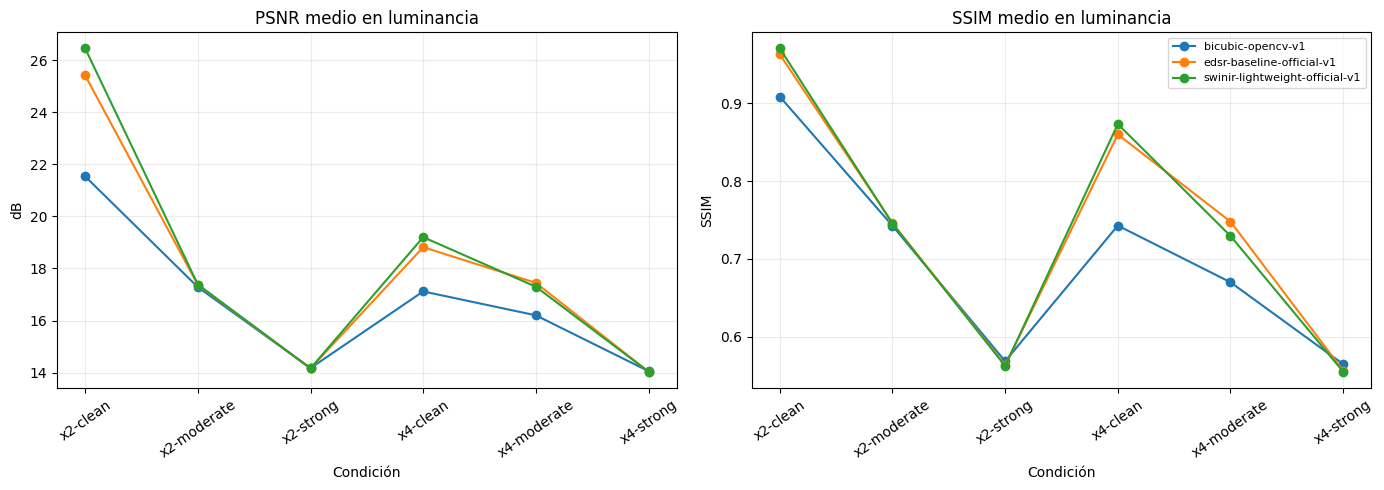

{'archive': '/kaggle/working/phase3-smb-evaluation.zip', 'bytes': 32340832, 'sha256': '668d03f5e804837ae0cac9c6ac051ad4af1eb6bbc4e77cec3d516bdc5a2826ec'}


/kaggle/working/phase3-smb-evaluation.zip

In [2]:
import hashlib
import json
import os
import platform
import shutil
import subprocess
from datetime import UTC, datetime
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import FileLink, display

project_root = Path("/kaggle/working/proyecto-tfg")
artifact_root = project_root / "artifacts/phase3-smb-evaluation"
results_path = artifact_root / "raw-metrics.csv"
results = pd.read_csv(results_path)

conditions = (
    "x2-clean",
    "x2-moderate",
    "x2-strong",
    "x4-clean",
    "x4-moderate",
    "x4-strong",
)
methods = (
    "bicubic-opencv-v1",
    "edsr-baseline-official-v1",
    "swinir-lightweight-official-v1",
)
keys = ["item_id", "condition_id", "method_id"]
metrics = ["psnr_y", "ssim_y", "psnr_rgb", "ssim_rgb"]
qualitative_files = sorted((artifact_root / "qualitative").rglob("*.png"))

checks = {
    "rows_1152": len(results) == 1152,
    "unique_tuples_1152": len(results.drop_duplicates(keys)) == 1152,
    "no_duplicates": not results.duplicated(keys).any(),
    "pages_64": results["item_id"].nunique() == 64,
    "source_groups_64": results["source_group_id"].nunique() == 64,
    "conditions_exact": set(results["condition_id"]) == set(conditions),
    "methods_exact": set(results["method_id"]) == set(methods),
    "three_methods_per_case": bool(
        (results.groupby(["item_id", "condition_id"])["method_id"].nunique() == 3).all()
    ),
    "metrics_complete": not results[metrics].isna().any().any(),
    "metrics_finite": bool(np.isfinite(results[metrics].to_numpy()).all()),
    "ssim_in_range": bool(
        results[["ssim_y", "ssim_rgb"]].isin([np.inf, -np.inf]).sum().sum() == 0
        and (results[["ssim_y", "ssim_rgb"]] <= 1).all().all()
        and (results[["ssim_y", "ssim_rgb"]] >= -1).all().all()
    ),
    "runtime_valid": bool(
        np.isfinite(results["runtime_seconds"]).all() and (results["runtime_seconds"] >= 0).all()
    ),
    "output_hashes_valid": bool(results["output_sha256"].str.fullmatch(r"[0-9a-f]{64}").all()),
    "degradation_traces_384": results["degradation_trace_id"].nunique() == 384,
    "qualitative_pngs_18": len(qualitative_files) == 18,
}

print(checks)
if not all(checks.values()):
    raise RuntimeError("La ejecución no supera la reconciliación.")

aggregate = results.groupby(["condition_id", "method_id"], as_index=False).agg(
    pages=("item_id", "nunique"),
    psnr_y_mean=("psnr_y", "mean"),
    ssim_y_mean=("ssim_y", "mean"),
    psnr_rgb_mean=("psnr_rgb", "mean"),
    ssim_rgb_mean=("ssim_rgb", "mean"),
    runtime_seconds_median=("runtime_seconds", "median"),
)
aggregate.to_csv(artifact_root / "aggregate-metrics.csv", index=False)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
for method in methods:
    frame = (
        aggregate[aggregate["method_id"] == method]
        .set_index("condition_id")
        .loc[list(conditions)]
        .reset_index()
    )
    axes[0].plot(frame["condition_id"], frame["psnr_y_mean"], marker="o", label=method)
    axes[1].plot(frame["condition_id"], frame["ssim_y_mean"], marker="o", label=method)

axes[0].set(title="PSNR medio en luminancia", ylabel="dB", xlabel="Condición")
axes[1].set(title="SSIM medio en luminancia", ylabel="SSIM", xlabel="Condición")
for axis in axes:
    axis.tick_params(axis="x", rotation=35)
    axis.grid(alpha=0.25)
axes[1].legend(fontsize=8)
figure.tight_layout()
figure.savefig(artifact_root / "metrics-overview.png", dpi=220, bbox_inches="tight")
plt.show()

git_revision = subprocess.run(
    ["git", "-C", str(project_root), "rev-parse", "HEAD"],
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

runtime_evidence = {
    "recorded_at": datetime.now(UTC).isoformat(),
    "git_revision": git_revision,
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "opencv": cv2.__version__,
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version(),
    "gpu_devices": [
        torch.cuda.get_device_name(index) for index in range(torch.cuda.device_count())
    ],
    "seed": 20260829,
    "validation": checks,
}
(artifact_root / "runtime-evidence.json").write_text(
    json.dumps(runtime_evidence, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

freeze = subprocess.run(
    ["uv", "pip", "freeze", "--system"],
    check=True,
    capture_output=True,
    text=True,
).stdout
(artifact_root / "environment-freeze.txt").write_text(freeze, encoding="utf-8")

frozen_inputs = artifact_root / "frozen-inputs"
frozen_inputs.mkdir(exist_ok=True)
shutil.copy2(
    project_root / "configs/experiments/smb-pretrained-evaluation-v1.yaml",
    frozen_inputs,
)
shutil.copy2(
    project_root / "configs/degradations/controlled-score-v1.yaml",
    frozen_inputs,
)
shutil.copytree(
    project_root / "configs/smb-evaluation-v1",
    frozen_inputs / "smb-evaluation-v1",
    dirs_exist_ok=True,
)


def sha256_file(path: Path) -> str:
    with path.open("rb") as source:
        return hashlib.file_digest(source, "sha256").hexdigest()


manifest = {
    str(path.relative_to(artifact_root)): {
        "bytes": path.stat().st_size,
        "sha256": sha256_file(path),
    }
    for path in sorted(artifact_root.rglob("*"))
    if path.is_file() and path.name != "artifact-manifest.json"
}
(artifact_root / "artifact-manifest.json").write_text(
    json.dumps(manifest, indent=2, sort_keys=True) + "\n",
    encoding="utf-8",
)

archive_path = Path(
    shutil.make_archive(
        "/kaggle/working/phase3-smb-evaluation",
        "zip",
        artifact_root,
    )
)
archive_sha256 = sha256_file(archive_path)

print(
    {
        "archive": str(archive_path),
        "bytes": archive_path.stat().st_size,
        "sha256": archive_sha256,
    }
)

os.chdir("/kaggle/working")
display(FileLink(archive_path.name))